### Credit Card Fraud Detection — Phase 4: Head-to-Head Comparison & Business Framing
### ULB Credit Card Fraud Dataset
 
Steps:
  1. Load predictions from Phase 2 (supervised) and Phase 3 (unsupervised)
  2. Full comparison table — all 4 models
  3. PR curves — all models on one chart
  4. Confusion matrices — all models
  5. Autoencoder score distribution
  6. Business cost framing — false alarm rate at 90% fraud recall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
MODEL_COLORS = {
    "Random Forest (supervised)": "#2ca02c",
    "Isolation Forest"          : "#4C72B0",
    "LOF"                       : "#FF7F0E",
    "Autoencoder"               : "#E07070",
}

In [3]:
sup   = pd.read_csv("fraud_supervised_predictions.csv")
unsup = pd.read_csv("fraud_unsupervised_predictions.csv")
 
y_test      = sup["y_true"].values
fraud_rate  = y_test.mean()
fraud_count = y_test.sum()
total       = len(y_test)
 
scores = {
    "Random Forest (supervised)": sup["supervised_prob"].values,
    "Isolation Forest"          : unsup["iso_score"].values,
    "Autoencoder"               : unsup["ae_score"].values,
}
preds = {
    "Random Forest (supervised)": sup["supervised_pred"].values,
    "Isolation Forest"          : unsup["iso_pred"].values,
    "Autoencoder"               : unsup["ae_pred"].values,
}
 
print("=" * 65)
print("PHASE 4 — FULL HEAD-TO-HEAD COMPARISON")
print("=" * 65)
print(f"Test set  : {total:,}  |  Fraud: {fraud_count} ({fraud_rate*100:.3f}%)")

PHASE 4 — FULL HEAD-TO-HEAD COMPARISON
Test set  : 56,962  |  Fraud: 98 (0.172%)


In [4]:
rows = []
for name, score in scores.items():
    pred = preds[name]
    cm   = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Model"    : name,
        "Paradigm" : "Supervised" if "supervised" in name.lower() else "Unsupervised",
        "PR-AUC"   : round(average_precision_score(y_test, score), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, score), 4),
        "Recall"   : round(recall_score(y_test, pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_test, pred, zero_division=0), 4),
        "FN"       : int(fn),
        "FP"       : int(fp),
    })
 
comp_df = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
print("\nFull comparison (sorted by PR-AUC):")
print(comp_df.to_string(index=False))


Full comparison (sorted by PR-AUC):
                     Model     Paradigm  PR-AUC  ROC-AUC  Recall  Precision     F1  FN   FP
Random Forest (supervised)   Supervised  0.8766   0.9646  0.8163     0.8696 0.8421  18   12
               Autoencoder Unsupervised  0.5067   0.9549  0.8469     0.0291 0.0563  15 2766
          Isolation Forest Unsupervised  0.1572   0.9570  0.3367     0.2245 0.2694  65  114


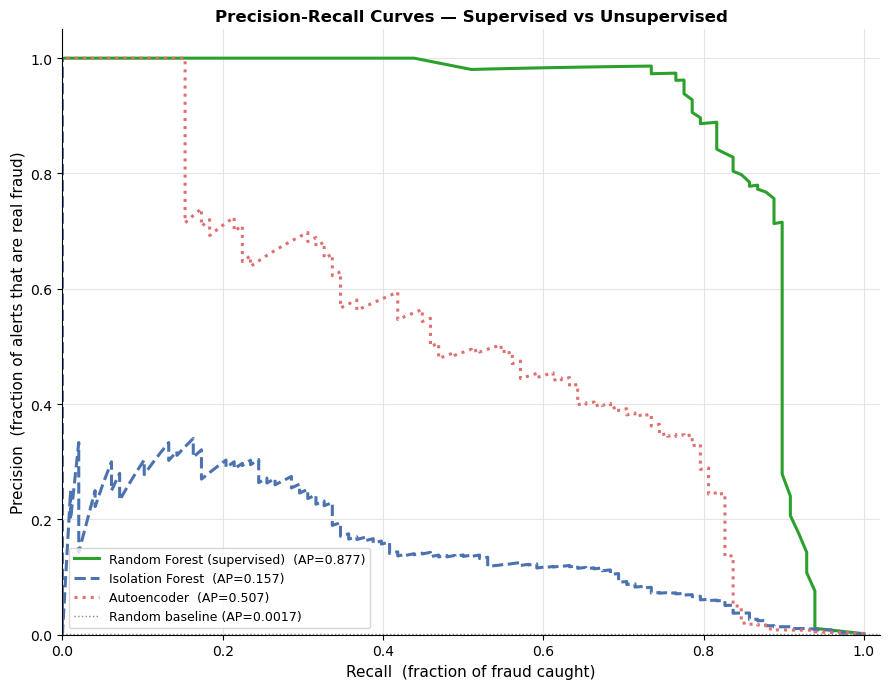

In [5]:
line_styles = {"Random Forest (supervised)": "-", "Isolation Forest": "--",
                "Autoencoder": ":"}
 
fig, ax = plt.subplots(figsize=(9, 7))
for name, score in scores.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test, score)
    ap = average_precision_score(y_test, score)
    ax.plot(rec_c, prec_c, color=MODEL_COLORS[name],
            linestyle=line_styles[name], linewidth=2.2,
            label=f"{name}  (AP={ap:.3f})")
 
ax.axhline(fraud_rate, color="#888", linestyle=":",
           linewidth=1, label=f"Random baseline (AP={fraud_rate:.4f})")
ax.set_xlabel("Recall  (fraction of fraud caught)", fontsize=11)
ax.set_ylabel("Precision  (fraction of alerts that are real fraud)", fontsize=11)
ax.set_title("Precision-Recall Curves — Supervised vs Unsupervised",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("phase4_pr_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()

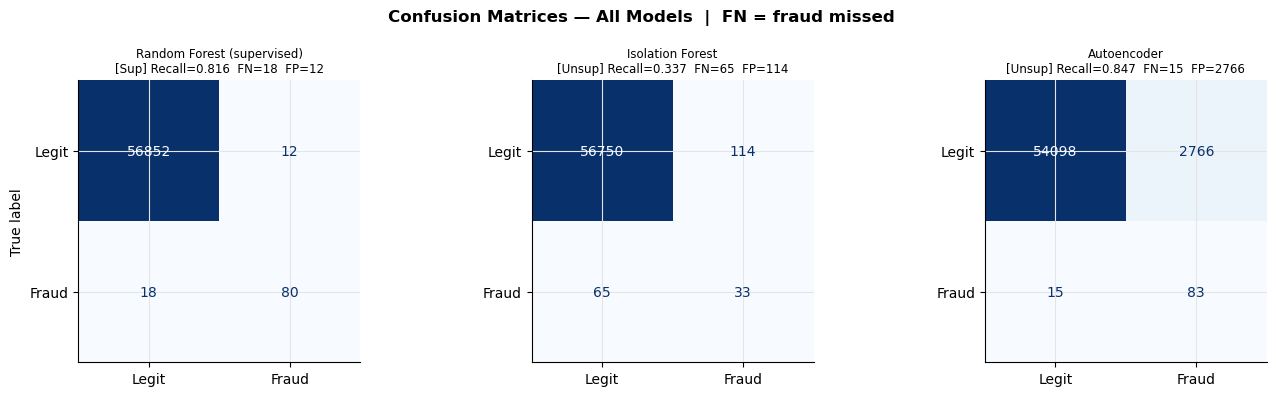

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Confusion Matrices — All Models  |  FN = fraud missed",
             fontweight="bold", fontsize=12)
 
for ax, (name, pred) in zip(axes, preds.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    tn, fp, fn, tp = cm.ravel()
    rec  = recall_score(y_test, pred, zero_division=0)
    para = "Sup" if "supervised" in name.lower() else "Unsup"
    ax.set_title(f"{name}\n[{para}] Recall={rec:.3f}  FN={fn}  FP={fp}",
                 fontsize=8.5)
    ax.set_xlabel("")
    ax.set_ylabel("True label" if name == "Random Forest (supervised)" else "")
 
plt.tight_layout()
plt.savefig("phase4_confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

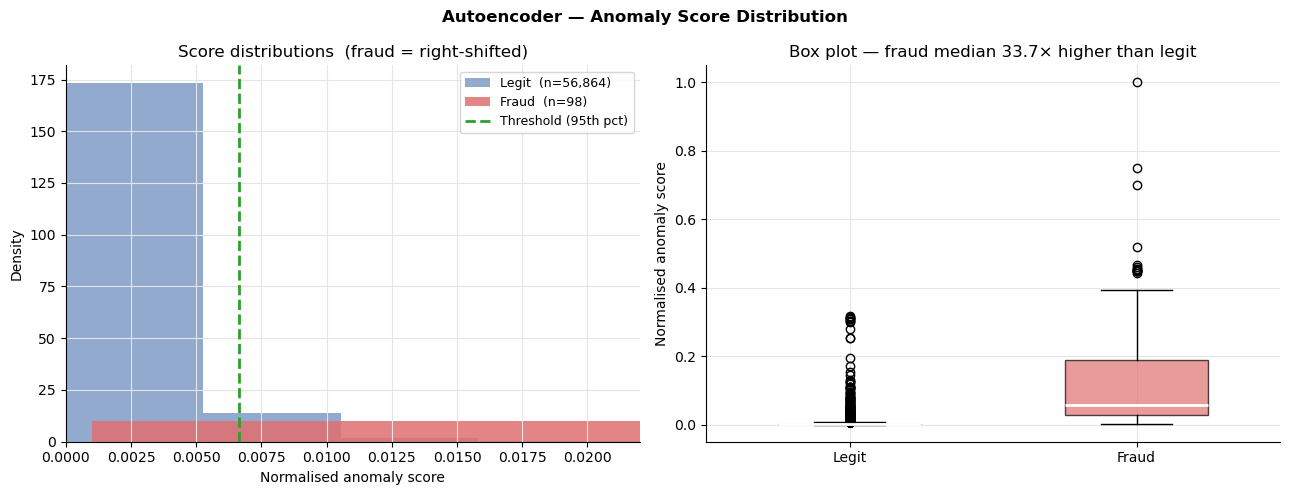

In [8]:
ae_scores    = scores["Autoencoder"]
legit_scores = ae_scores[y_test == 0]
fraud_scores = ae_scores[y_test == 1]
threshold_ae = np.percentile(ae_scores, 95)
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Autoencoder — Anomaly Score Distribution", fontweight="bold")
 
ax = axes[0]
ax.hist(legit_scores, bins=60, color="#4C72B0", alpha=0.6,
        density=True, label=f"Legit  (n={len(legit_scores):,})", edgecolor="none")
ax.hist(fraud_scores, bins=30, color="#E07070", alpha=0.85,
        density=True, label=f"Fraud  (n={len(fraud_scores)})", edgecolor="none")
ax.axvline(threshold_ae, color="#2ca02c", linestyle="--",
           linewidth=2, label="Threshold (95th pct)")
ax.set_xlabel("Normalised anomaly score")
ax.set_ylabel("Density")
ax.set_title("Score distributions  (fraud = right-shifted)")
ax.legend(fontsize=9)
ax.set_xlim(0, np.percentile(ae_scores, 99.5))
 
ax2 = axes[1]
bp  = ax2.boxplot([legit_scores, fraud_scores], positions=[1, 2],
                  patch_artist=True, widths=0.5,
                  medianprops={"color": "white", "linewidth": 2})
bp["boxes"][0].set_facecolor("#4C72B0"); bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("#E07070"); bp["boxes"][1].set_alpha(0.7)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Legit", "Fraud"])
ax2.set_ylabel("Normalised anomaly score")
ratio = np.median(fraud_scores) / max(np.median(legit_scores), 1e-9)
ax2.set_title(f"Box plot — fraud median {ratio:.1f}× higher than legit")
 
plt.tight_layout()
plt.savefig("phase4_autoencoder_scores.png", dpi=150, bbox_inches="tight")
plt.show()


BUSINESS COST @ 90% RECALL  (per 10,000 transactions)
  Random Forest (supervised)          FP/10k=   40  Analyst hrs=3.3
  Isolation Forest                    FP/10k=1,109  Analyst hrs=92.4
  Autoencoder                         FP/10k=1,856  Analyst hrs=154.7


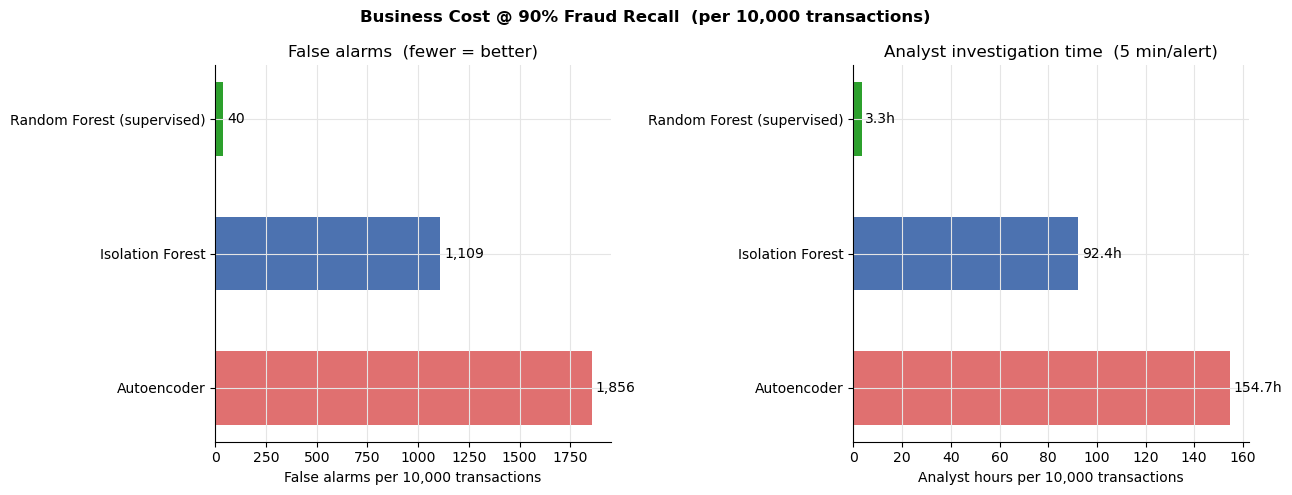

In [9]:
#    At 90% recall, how many false alarms per 10,000 transactions?
# ════════════════════════════════════════════════════════════════════════════
 
TARGET_RECALL = 0.90
TRANSACTIONS  = 10_000
ANALYST_MINS  = 5
 
print(f"\n{'='*65}")
print(f"BUSINESS COST @ {TARGET_RECALL*100:.0f}% RECALL  "
      f"(per {TRANSACTIONS:,} transactions)")
print(f"{'='*65}")
 
biz_rows = []
for name, score in scores.items():
    prec_c, rec_c, thresh_c = precision_recall_curve(y_test, score)
    idx = np.searchsorted(-rec_c, -TARGET_RECALL)
    if idx >= len(thresh_c):
        idx = len(thresh_c) - 1
    achieved_rec  = rec_c[idx]
    achieved_prec = prec_c[idx]
    fp_per_10k = int(
        (TRANSACTIONS * fraud_rate * achieved_rec * (1 - achieved_prec))
        / max(achieved_prec, 1e-9)
    )
    analyst_hrs = round(fp_per_10k * ANALYST_MINS / 60, 1)
    biz_rows.append({
        "Model"              : name,
        "Achieved Recall"    : round(achieved_rec, 3),
        "Precision @ Recall" : round(achieved_prec, 3),
        "False Alarms / 10k" : fp_per_10k,
        "Analyst Hrs / 10k"  : analyst_hrs,
    })
    print(f"  {name:<35} FP/10k={fp_per_10k:>5,}  "
          f"Analyst hrs={analyst_hrs:.1f}")
 
biz_df = pd.DataFrame(biz_rows).sort_values("False Alarms / 10k")
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Business Cost @ {TARGET_RECALL*100:.0f}% Fraud Recall  "
             f"(per {TRANSACTIONS:,} transactions)", fontweight="bold")
 
names      = biz_df["Model"].tolist()
fa_vals    = biz_df["False Alarms / 10k"].tolist()
hr_vals    = biz_df["Analyst Hrs / 10k"].tolist()
bar_colors = [MODEL_COLORS.get(n, "#888") for n in names]
 
ax = axes[0]
bars = ax.barh(names, fa_vals, color=bar_colors, height=0.55)
ax.set_xlabel(f"False alarms per {TRANSACTIONS:,} transactions")
ax.set_title("False alarms  (fewer = better)")
ax.invert_yaxis()
for bar, v in zip(bars, fa_vals):
    ax.text(bar.get_width() + max(fa_vals)*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{v:,}", va="center", fontsize=10)
 
ax2 = axes[1]
bars2 = ax2.barh(names, hr_vals, color=bar_colors, height=0.55)
ax2.set_xlabel("Analyst hours per 10,000 transactions")
ax2.set_title(f"Analyst investigation time  ({ANALYST_MINS} min/alert)")
ax2.invert_yaxis()
for bar, v in zip(bars2, hr_vals):
    ax2.text(bar.get_width() + max(hr_vals)*0.01,
             bar.get_y() + bar.get_height()/2,
             f"{v:.1f}h", va="center", fontsize=10)
 
plt.tight_layout()
plt.savefig("phase4_business_cost.png", dpi=150, bbox_inches="tight")
plt.show()